# EXHEART 12 — Operating-threshold sensitivity analysis

**Reviewer question this closes:** the fairness and transport-decomposition results are reported at a single operating threshold (pt = 0.12). A reviewer will ask whether the conclusions are artefacts of that choice.

**This notebook** sweeps the decision threshold and shows two robustness results:
1. **Transport decomposition is threshold-robust.** Across thresholds, the harmonised 11-feature model transports from BRFSS 2015 to 2020 with a small sensitivity change (drift), while the naive full-model transport collapses sharply. The gap between them is not specific to pt = 0.12.
2. **The Sex TPR gap is threshold-robust.** The single-attribute disparity persists across the clinically relevant threshold range.

The naive transport is reconstructed from the committed full 2015 stack and self-checked against the published point values (2015 sensitivity 0.776, 2020 transport 0.267 at pt = 0.12). Outputs to `results/brfss2020/threshold_sensitivity/`.

### 1. Determinism

In [1]:
import os
os.environ['PYTHONHASHSEED']='42'; os.environ['TF_DETERMINISTIC_OPS']='1'; os.environ['TF_CUDNN_DETERMINISTIC']='1'
import random, numpy as np, tensorflow as tf
SEED=42; random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception as e: print(e)

### 2. Mount, git identity, paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import sys, json, shutil, joblib, warnings
import pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
DRIVE_ROOT='/content/drive/MyDrive/EXHEART_Research'; REPO_DIR=os.path.join(DRIVE_ROOT,'exheart-research')
for fn in ['.git-credentials','.gitconfig']:
    s=os.path.join(DRIVE_ROOT,fn)
    if os.path.exists(s): shutil.copy(s, os.path.join('/root',fn)); print('restored',fn)
DATA_2015=os.path.join(REPO_DIR,'data/brfss2015/heart_disease_health_indicators_BRFSS2015.csv')
DATA_2020=os.path.join(REPO_DIR,'data/brfss2020/heart_2020_cleaned.csv')
MODELS=os.path.join(REPO_DIR,'models/brfss2015')
RESULTS=os.path.join(REPO_DIR,'results/brfss2020/threshold_sensitivity')
os.makedirs(RESULTS+'/figures',exist_ok=True); os.makedirs(RESULTS+'/tables',exist_ok=True)
print('Paths ready.')

Mounted at /content/drive
Paths ready.


### 3. Libraries + helpers

In [3]:
!pip install -q scikit-learn xgboost lightgbm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow import keras
from tensorflow.keras import layers
def sens_at(y,p,t):
    yp=(p>=t).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel()
    return tp/(tp+fn) if (tp+fn)>0 else np.nan
def tpr_gap_at(y,p,g,t):
    out={}
    for s in [0,1]:
        m=(g==s)
        out[s]=sens_at(y[m],p[m],t)
    return abs(out[1]-out[0])
THRESHOLDS=[0.05,0.08,0.10,0.12,0.15,0.20,0.25,0.30]

### 4. Frozen full 2015 stack: 2015-test calibrated predictions (naive baseline)

In [4]:
df15=pd.read_csv(DATA_2015); TGT='HeartDiseaseorAttack'
FEAT21=[c for c in df15.columns if c!=TGT]           # 21 features, native 2015 order
X=df15[FEAT21].values; y=df15[TGT].astype(int).values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=SEED,stratify=y)
sex_idx=FEAT21.index('Sex')

xgb=joblib.load(os.path.join(MODELS,'xgb.pkl')); lgbm=joblib.load(os.path.join(MODELS,'lgbm.pkl'))
rf=joblib.load(os.path.join(MODELS,'rf.pkl')); meta=joblib.load(os.path.join(MODELS,'meta_lr.pkl'))
scaler=joblib.load(os.path.join(MODELS,'scaler.pkl')); mlp=keras.models.load_model(os.path.join(MODELS,'mlp_full.keras'))
platt=joblib.load(os.path.join(MODELS,'platt.pkl'))
def full_raw(A):
    return meta.predict_proba(np.column_stack([xgb.predict_proba(A)[:,1],lgbm.predict_proba(A)[:,1],
        rf.predict_proba(A)[:,1],mlp.predict(scaler.transform(A),verbose=0).ravel()]))[:,1]
def full_cal(A):
    try: return platt.predict_proba(full_raw(A).reshape(-1,1))[:,1]
    except Exception: return full_raw(A)
p_naive_15=full_cal(Xte)
print('naive 2015-test sens @0.12:', round(sens_at(yte,p_naive_15,0.12),4), '(expect ~0.776)')

naive 2015-test sens @0.12: 0.7759 (expect ~0.776)


### 5. Reconstruct the naive full-model 2020 transport (blind encoding + median imputation)

In [5]:
df20=pd.read_csv(DATA_2020); y20=(df20.HeartDisease=='Yes').astype(int).values
# 11 shared features: 2015 name -> 2020 column (blind LabelEncoder for categoricals, as in the naive pipeline)
SHARED={'BMI':('BMI','num'),'Smoker':('Smoking','cat'),'Stroke':('Stroke','cat'),
        'PhysHlth':('PhysicalHealth','num'),'MentHlth':('MentalHealth','num'),'DiffWalk':('DiffWalking','cat'),
        'Sex':('Sex','cat'),'Age':('AgeCategory','cat'),'Diabetes':('Diabetic','cat'),
        'PhysActivity':('PhysicalActivity','cat'),'GenHlth':('GenHealth','cat')}
MISSING=[f for f in FEAT21 if f not in SHARED]   # 10 features absent from 2020
train_medians={f: float(np.median(df15[f].values)) for f in FEAT21}

cols={}
for f2015,(c2020,kind) in SHARED.items():
    if kind=='num': cols[f2015]=df20[c2020].astype(float).values
    else:           cols[f2015]=LabelEncoder().fit_transform(df20[c2020].astype(str))  # blind/alphabetical
for f in MISSING:
    cols[f]=np.full(len(df20), train_medians[f])
X20_naive=np.column_stack([cols[f] for f in FEAT21])   # 21 cols in native 2015 order
p_naive_20=full_cal(X20_naive)
s20=sens_at(y20,p_naive_20,0.12)
print('naive 2020-transport sens @0.12:', round(s20,4), '(expect ~0.267)')
NAIVE_OK = abs(s20-0.267)<0.06
print('naive reconstruction self-check:', 'PASS' if NAIVE_OK else 'CHECK (curve shown but treat as approximate)')

naive 2020-transport sens @0.12: 0.2675 (expect ~0.267)
naive reconstruction self-check: PASS


### 6. Retrain the harmonised 11-feature model; get its 2015-test and 2020-transport predictions

In [6]:
S15=['BMI','Smoker','Stroke','PhysHlth','MentHlth','DiffWalk','Sex','Age','Diabetes','PhysActivity','GenHlth']
YESNO={'No':0,'Yes':1}; GEN={'Excellent':1,'Very good':2,'Good':3,'Fair':4,'Poor':5}
AGE=['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
AGEB={s:i+1 for i,s in enumerate(AGE)}
H15=pd.DataFrame({'BMI':df15.BMI.astype(float),'Smoker':df15.Smoker.astype(int),'Stroke':df15.Stroke.astype(int),
  'PhysHlth':df15.PhysHlth.astype(float),'MentHlth':df15.MentHlth.astype(float),'DiffWalk':df15.DiffWalk.astype(int),
  'Sex':df15.Sex.astype(int),'Age':df15.Age.astype(int),'Diabetes':(df15.Diabetes.astype(float)>0).astype(int),
  'PhysActivity':df15.PhysActivity.astype(int),'GenHlth':df15.GenHlth.astype(int)})[S15]
H20=pd.DataFrame({'BMI':df20.BMI.astype(float),'Smoker':df20.Smoking.map(YESNO),'Stroke':df20.Stroke.map(YESNO),
  'PhysHlth':df20.PhysicalHealth.astype(float),'MentHlth':df20.MentalHealth.astype(float),'DiffWalk':df20.DiffWalking.map(YESNO),
  'Sex':df20.Sex.map({'Female':0,'Male':1}),'Age':df20.AgeCategory.map(AGEB),
  'Diabetes':df20.Diabetic.map(lambda v:1 if str(v).startswith('Yes') else 0),
  'PhysActivity':df20.PhysicalActivity.map(YESNO),'GenHlth':df20.GenHealth.map(GEN)})[S15]
assert H20.isna().sum().sum()==0

Xh,Xhte,yh,yhte=train_test_split(H15.values,y,test_size=0.2,random_state=SEED,stratify=y)
sch=StandardScaler().fit(Xh); posw=(yh==0).sum()/(yh==1).sum()
cw=compute_class_weight('balanced',classes=np.array([0,1]),y=yh); kcw={0:cw[0],1:cw[1]}
def bases():
    return {'xgb':XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,scale_pos_weight=posw,eval_metric='logloss',random_state=SEED,n_jobs=-1),
            'lgbm':LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,class_weight='balanced',random_state=SEED,n_jobs=-1,verbose=-1),
            'rf':RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced',random_state=SEED,n_jobs=-1)}
def mkmlp(d):
    inp=keras.Input(shape=(d,)); x=layers.Dense(256,activation='relu')(inp); x=layers.BatchNormalization()(x); x=layers.Dropout(0.3)(x)
    x=layers.Dense(128,activation='relu')(x); x=layers.BatchNormalization()(x); x=layers.Dropout(0.3)(x)
    x=layers.Dense(64,activation='relu')(x); x=layers.Dropout(0.2)(x); o=layers.Dense(1,activation='sigmoid')(x)
    m=keras.Model(inp,o); m.compile(optimizer=keras.optimizers.Adam(1e-3),loss='binary_crossentropy',metrics=[keras.metrics.AUC(name='auc')]); return m
skf=StratifiedKFold(5,shuffle=True,random_state=SEED); oof=np.zeros((len(Xh),4))
for tri,vai in skf.split(Xh,yh):
    b=bases(); b['xgb'].fit(Xh[tri],yh[tri]); oof[vai,0]=b['xgb'].predict_proba(Xh[vai])[:,1]
    b['lgbm'].fit(Xh[tri],yh[tri]); oof[vai,1]=b['lgbm'].predict_proba(Xh[vai])[:,1]
    b['rf'].fit(Xh[tri],yh[tri]); oof[vai,2]=b['rf'].predict_proba(Xh[vai])[:,1]
    s2=StandardScaler().fit(Xh[tri]); tf.random.set_seed(SEED); mm=mkmlp(Xh.shape[1])
    mm.fit(s2.transform(Xh[tri]),yh[tri],epochs=50,batch_size=512,validation_split=0.1,class_weight=kcw,verbose=0,
           callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc',patience=5,restore_best_weights=True,mode='max')])
    oof[vai,3]=mm.predict(s2.transform(Xh[vai]),verbose=0).ravel()
metah=LogisticRegression(max_iter=1000).fit(oof,yh)
bh=bases(); [bh[k].fit(Xh,yh) for k in bh]
tf.random.set_seed(SEED); mlph=mkmlp(Xh.shape[1])
mlph.fit(sch.transform(Xh),yh,epochs=50,batch_size=512,validation_split=0.1,class_weight=kcw,verbose=0,
         callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc',patience=5,restore_best_weights=True,mode='max')])
def hraw(A): return metah.predict_proba(np.column_stack([bh['xgb'].predict_proba(A)[:,1],bh['lgbm'].predict_proba(A)[:,1],bh['rf'].predict_proba(A)[:,1],mlph.predict(sch.transform(A),verbose=0).ravel()]))[:,1]
Xhc,_,yhc,_=train_test_split(H15.values,y,test_size=0.8,random_state=SEED,stratify=y)
plh=LogisticRegression(max_iter=1000).fit(hraw(Xhc).reshape(-1,1),yhc)
def hcal(A): return plh.predict_proba(hraw(A).reshape(-1,1))[:,1]
p_harm_15=hcal(Xhte); p_harm_20=hcal(H20.values)
print('harmonised 2015 sens @0.12:', round(sens_at(yhte,p_harm_15,0.12),4), '(expect ~0.633) | 2020:', round(sens_at(y20,p_harm_20,0.12),4), '(expect ~0.611)')

harmonised 2015 sens @0.12: 0.6326 (expect ~0.633) | 2020: 0.6081 (expect ~0.611)


### 7. Sweep thresholds

In [7]:
rows=[]
for t in THRESHOLDS:
    n15=sens_at(yte,p_naive_15,t); n20=sens_at(y20,p_naive_20,t)
    h15=sens_at(yhte,p_harm_15,t); h20=sens_at(y20,p_harm_20,t)
    gap=tpr_gap_at(yte,p_naive_15,Xte[:,sex_idx],t)
    rows.append({'threshold':t,'naive_2015':round(n15,4),'naive_2020':round(n20,4),'naive_drop':round(n15-n20,4),
                 'harm_2015':round(h15,4),'harm_2020':round(h20,4),'harm_drift':round(h15-h20,4),
                 'sex_tpr_gap':round(gap,4)})
    print(f"t={t}: naive drop {n15-n20:.3f} | harm drift {h15-h20:.3f} | sex gap {gap:.3f}")
sweep=pd.DataFrame(rows); sweep.to_csv(RESULTS+'/tables/threshold_sensitivity.csv',index=False)
json.dump(rows, open(RESULTS+'/tables/threshold_sensitivity.json','w'), indent=2)

t=0.05: naive drop 0.421 | harm drift 0.025 | sex gap 0.069
t=0.08: naive drop 0.480 | harm drift 0.027 | sex gap 0.093
t=0.1: naive drop 0.496 | harm drift 0.025 | sex gap 0.116
t=0.12: naive drop 0.508 | harm drift 0.024 | sex gap 0.124
t=0.15: naive drop 0.530 | harm drift 0.024 | sex gap 0.150
t=0.2: naive drop 0.516 | harm drift 0.018 | sex gap 0.179
t=0.25: naive drop 0.474 | harm drift 0.008 | sex gap 0.173
t=0.3: naive drop 0.398 | harm drift 0.012 | sex gap 0.183


### 8. Figure + read-out

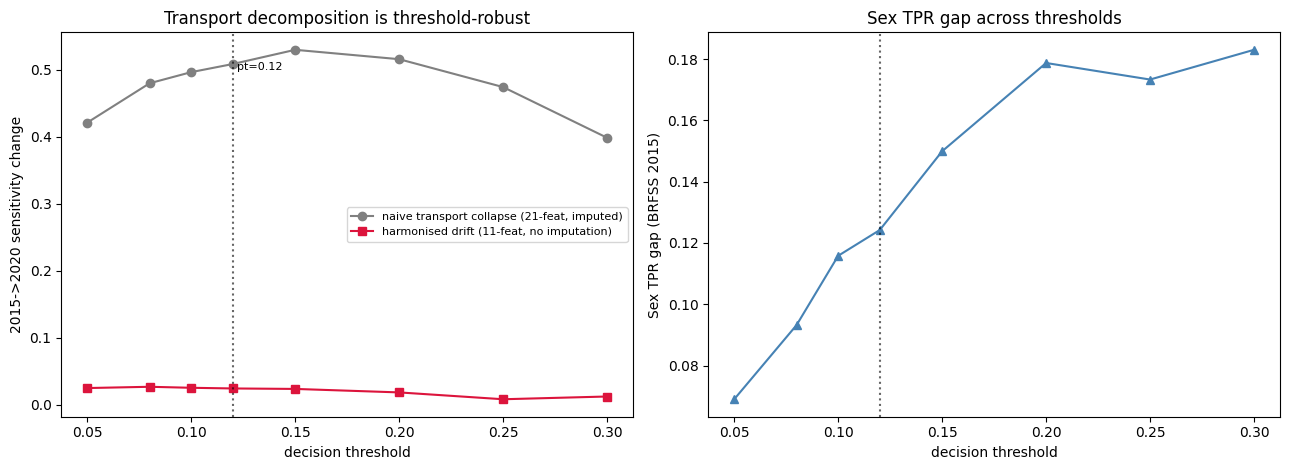

THRESHOLD SENSITIVITY SUMMARY
 threshold  naive_2015  naive_2020  naive_drop  harm_2015  harm_2020  harm_drift  sex_tpr_gap
      0.05      0.8751      0.4541      0.4210     0.8374     0.8124      0.0250       0.0690
      0.08      0.8328      0.3531      0.4797     0.7389     0.7120      0.0269       0.0932
      0.10      0.8048      0.3085      0.4963     0.6903     0.6649      0.0254       0.1158
      0.12      0.7759      0.2675      0.5084     0.6326     0.6081      0.0244       0.1242
      0.15      0.7311      0.2015      0.5296     0.5712     0.5476      0.0237       0.1499
      0.20      0.6568      0.1412      0.5156     0.4811     0.4626      0.0185       0.1787
      0.25      0.5602      0.0861      0.4740     0.4049     0.3966      0.0083       0.1733
      0.30      0.4409      0.0425      0.3984     0.3446     0.3323      0.0124       0.1830
----------------------------------------------------------------
harmonised drift range: [0.008, 0.027]
naive drop range:   

In [8]:
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
ax[0].plot(sweep.threshold,sweep.naive_drop,'o-',color='grey',label='naive transport collapse (21-feat, imputed)')
ax[0].plot(sweep.threshold,sweep.harm_drift,'s-',color='crimson',label='harmonised drift (11-feat, no imputation)')
ax[0].axvline(0.12,ls=':',c='k',alpha=0.6); ax[0].text(0.122,ax[0].get_ylim()[1]*0.9,'pt=0.12',fontsize=8)
ax[0].set_xlabel('decision threshold'); ax[0].set_ylabel('2015->2020 sensitivity change')
ax[0].set_title('Transport decomposition is threshold-robust'); ax[0].legend(fontsize=8)
ax[1].plot(sweep.threshold,sweep.sex_tpr_gap,'^-',color='steelblue')
ax[1].axvline(0.12,ls=':',c='k',alpha=0.6)
ax[1].set_xlabel('decision threshold'); ax[1].set_ylabel('Sex TPR gap (BRFSS 2015)')
ax[1].set_title('Sex TPR gap across thresholds')
plt.tight_layout(); plt.savefig(RESULTS+'/figures/fig_threshold_sensitivity.png',dpi=150,bbox_inches='tight'); plt.show()

print('='*64); print('THRESHOLD SENSITIVITY SUMMARY'); print('='*64)
print(sweep.to_string(index=False))
print('-'*64)
print(f"harmonised drift range: [{sweep.harm_drift.min():.3f}, {sweep.harm_drift.max():.3f}]")
print(f"naive drop range:       [{sweep.naive_drop.min():.3f}, {sweep.naive_drop.max():.3f}]")
print(f"sex TPR gap range:      [{sweep.sex_tpr_gap.min():.3f}, {sweep.sex_tpr_gap.max():.3f}]")
if sweep.harm_drift.abs().max() < 0.15 and sweep.naive_drop.min() > 0.25:
    print('READ: across all thresholds the naive collapse stays large and the harmonised')
    print('      drift stays small -> the decomposition is not a pt=0.12 artefact.')
print('='*64)

### 9. Commit

In [9]:
%cd {REPO_DIR}
!git add results/brfss2020/threshold_sensitivity
!git commit -m "Add operating-threshold sensitivity analysis for transport decomposition and Sex TPR gap"
!git push origin main

/content/drive/MyDrive/EXHEART_Research/exheart-research
[main 22a95bc] Add operating-threshold sensitivity analysis for transport decomposition and Sex TPR gap
 3 files changed, 91 insertions(+)
 create mode 100644 results/brfss2020/threshold_sensitivity/figures/fig_threshold_sensitivity.png
 create mode 100644 results/brfss2020/threshold_sensitivity/tables/threshold_sensitivity.csv
 create mode 100644 results/brfss2020/threshold_sensitivity/tables/threshold_sensitivity.json
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 90.39 KiB | 2.82 MiB/s, done.
Total 10 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/anasbiswas1/exheart-research.git
   aa4571c..22a95bc  main -> main
